## 1. Sprint 1 Planning

**Sprint 1 goal (confirmed):** *Understand the data and establish a baseline model to beat.*

**Backlog for this sprint:**
- [x] Dataset finalization
- [x] Brief EDA recap (full EDA already completed in `01_data_preparation.ipynb`)
- [x] Baseline model + recorded metric (this notebook)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)


df = pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/heart_disease_clean.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1316, 9)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [ ]:
# 3. Brief EDA Recap
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\n",df['Result'].value_counts(normalize=True).round(3))


Missing values: 0
Duplicate rows: 0

 Result
positive    0.614
negative    0.386
Name: proportion, dtype: float64


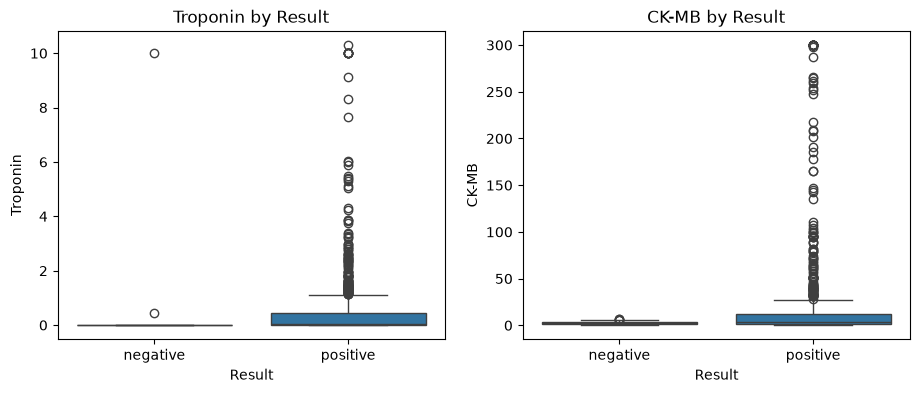

In [ ]:
numeric_cols = ['Age', 'Heart rate', 'Systolic blood pressure',
                'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x='Result', y='Troponin', ax=axes[0])
axes[0].set_title('Troponin by Result')


sns.boxplot(data=df, x='Result', y='CK-MB', ax=axes[1])
axes[1].set_title('CK-MB by Result')

plt.show()


Confirms what was found earlier: Troponin and CK-MB are clearly higher in positive cases 
The dataset is clean and ready for a baseline model.

In [ ]:
# 4. Baseline Model — Logistic Regression

X = df.drop(columns=['Result'])
y = df['Result'].map({'negative': 0, 'positive': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

baseline_scores = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_proba),
}

for metric, score in baseline_scores.items():
    print(f"{metric}: {score:.3f}")


Accuracy: 0.792
Precision: 0.828
Recall: 0.833
F1 Score: 0.831
ROC-AUC: 0.889


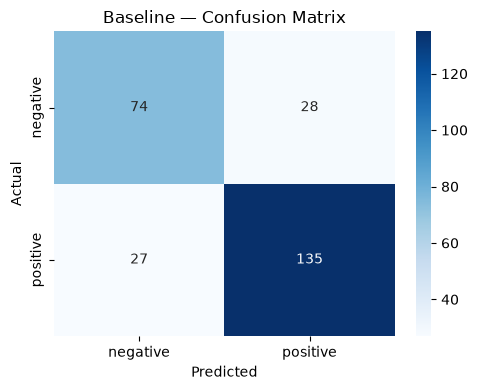

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline — Confusion Matrix')
plt.tight_layout()
plt.show()


 ## The Number to Beat
**Recall and F1 are the primary metrics to beat**, not raw accuracy — a missed heart attack case
(false negative) is far more costly than a false alarm, as established in the earlier confusion
matrix analysis

In [ ]:
# Baseline Score 
print("BASELINE TO BEAT (Logistic Regression, test set):")

for metric, score in baseline_scores.items():
    print(f"  {metric}: {score:.3f}")


BASELINE TO BEAT (Logistic Regression, test set):
  Accuracy: 0.792
  Precision: 0.828
  Recall: 0.833
  F1 Score: 0.831
  ROC-AUC: 0.889
